<a href="https://colab.research.google.com/github/felondrum/llm_driven_development_otus/blob/develop/hw1_attention_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ДЗ №1: Визуализация механизмов Attention в трансформерах

## 🎯 Цель задания
После выполнения задания вы сможете:
- Визуализировать работу self-attention механизма
- Сравнивать различные реализации QKV в BERT, GPT и T5
- Анализировать позиционные векторы и их влияние на понимание последовательности
- Интерпретировать attention-карты для объяснения решений модели

## 📝 Структура задания
- **Часть 1** (обязательная, 70% оценки): Базовая визуализация attention
- **Часть 2** (дополнительная, 30% оценки): Продвинутый анализ

## ⚡ Критерии оценки
- Корректность кода: 40%
- Качество визуализации: 30%
- Анализ результатов: 30%


## 🔧 Установка зависимостей

Установим необходимые библиотеки для работы с трансформерами и визуализации.


In [1]:
%pip install transformers torch matplotlib seaborn bertviz numpy pandas
%pip install -q ipywidgets


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
# Импорт необходимых библиотек
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import (
    AutoTokenizer, AutoModel,
    BertTokenizer, BertModel,
    GPT2Tokenizer, GPT2Model,
    T5Tokenizer, T5Model, 
    AutoModelForSeq2SeqLM
)

from bertviz import model_view, head_view
import warnings
warnings.filterwarnings('ignore')

# Настройка отображения
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline


## 📊 Часть 1: Основные задания (обязательная часть)

### Задание 1.1: Загрузка и подготовка моделей


In [9]:
# Загружаем модели для сравнения
models_info = {
    'BERT': {
        'model_name': 'bert-base-uncased',
        'tokenizer': None,
        'model': None
    },
    'GPT-2': {
        'model_name': 'gpt2',
        'tokenizer': None,
        'model': None
    },
    'T5-encoder': {
        'model_name': 'google-t5/t5-small',
        'tokenizer': None,
        'model': None
    }
}


models_info['BERT']['tokenizer'] = BertTokenizer.from_pretrained('bert-base-uncased')
models_info['BERT']['model'] = BertModel.from_pretrained('bert-base-uncased', output_attentions=True)
models_info['GPT-2']['tokenizer'] = GPT2Tokenizer.from_pretrained('gpt2')
models_info['GPT-2']['model'] = GPT2Model.from_pretrained('gpt2', output_attentions=True)
models_info['T5-encoder']['tokenizer'] = AutoTokenizer.from_pretrained("google-t5/t5-small")
models_info['T5-encoder']['model'] = AutoModelForSeq2SeqLM.from_pretrained("google-t5/t5-small", output_attentions=True)

print("Модели загружены успешно!")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Модели загружены успешно!


### Задание 1.2: Токенизация и получение attention весов

In [29]:
# Тестовый текст для анализа
test_text = "The cat sat on the mat and looked at the dog."
print(f"Анализируемый текст: {test_text}")

def get_attention_weights(text, model_name):
    """
    Получение attention весов для заданного текста и модели
    """
    tokenizer = models_info[model_name]['tokenizer']
    model = models_info[model_name]['model']

    inputs = tokenizer(test_text, return_tensors='pt')
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
    
    if model_name == "T5-encoder":
        decoder_input_ids = torch.tensor([[0]])
        with torch.no_grad():
            outputs = model(
                input_ids=inputs.input_ids,
                attention_mask=inputs.attention_mask,
                decoder_input_ids=decoder_input_ids,
                output_attentions=True
            )
        attention_weights = outputs.encoder_attentions
    else:    
        outputs = model(**inputs)
        attention_weights = outputs.attentions        

    return attention_weights, tokens, inputs

# Получаем attention веса для обеих моделей
bert_attention, bert_tokens, bert_inputs = get_attention_weights(test_text, 'BERT')
gpt2_attention, gpt2_tokens, gpt2_inputs = get_attention_weights(test_text, 'GPT-2')
t5e_attention, t5e_tokens, t5e_inputs = get_attention_weights(test_text, 'T5-encoder')

print(f"BERT tokens: {bert_tokens}")
print(f"GPT-2 tokens: {gpt2_tokens}")
print(f"T5 tokens: {t5e_tokens}")
print(f"BERT attention shape: {bert_attention[0].shape}")
print(f"GPT-2 attention shape: {gpt2_attention[0].shape}")
print(f"T5 attention shape: {t5e_attention[0].shape}")


Анализируемый текст: The cat sat on the mat and looked at the dog.
BERT tokens: ['[CLS]', 'the', 'cat', 'sat', 'on', 'the', 'mat', 'and', 'looked', 'at', 'the', 'dog', '.', '[SEP]']
GPT-2 tokens: ['The', 'Ġcat', 'Ġsat', 'Ġon', 'Ġthe', 'Ġmat', 'Ġand', 'Ġlooked', 'Ġat', 'Ġthe', 'Ġdog', '.']
T5 tokens: ['▁The', '▁cat', '▁', 's', 'at', '▁on', '▁the', '▁mat', '▁and', '▁looked', '▁at', '▁the', '▁dog', '.', '</s>']
BERT attention shape: torch.Size([1, 12, 14, 14])
GPT-2 attention shape: torch.Size([1, 12, 12, 12])
T5 attention shape: torch.Size([1, 8, 15, 15])


### Задание 1.3: Создание базовой attention heatmap

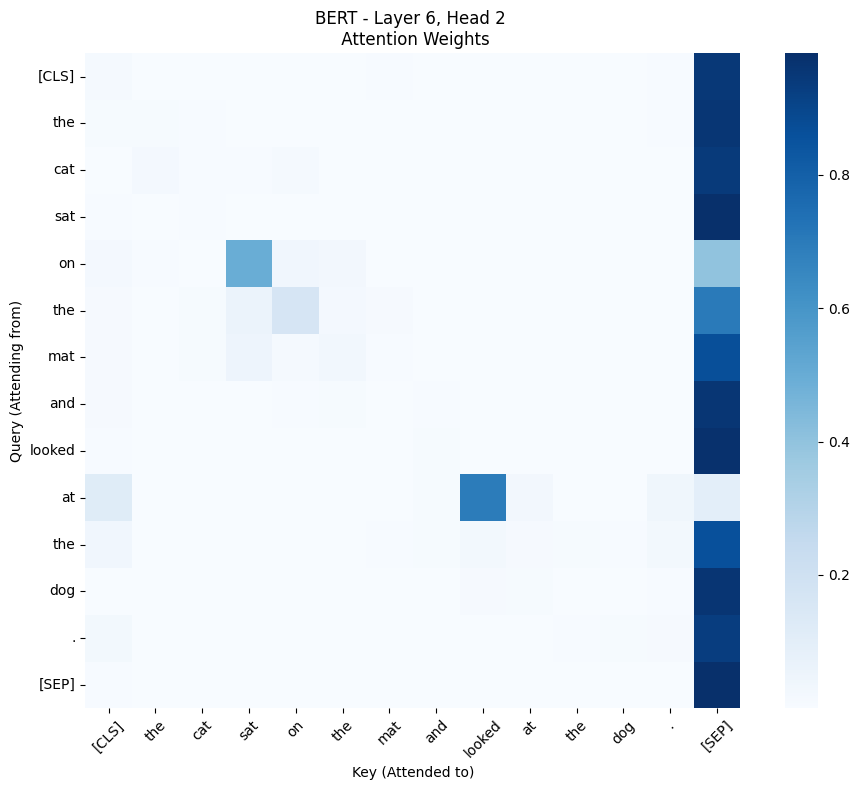

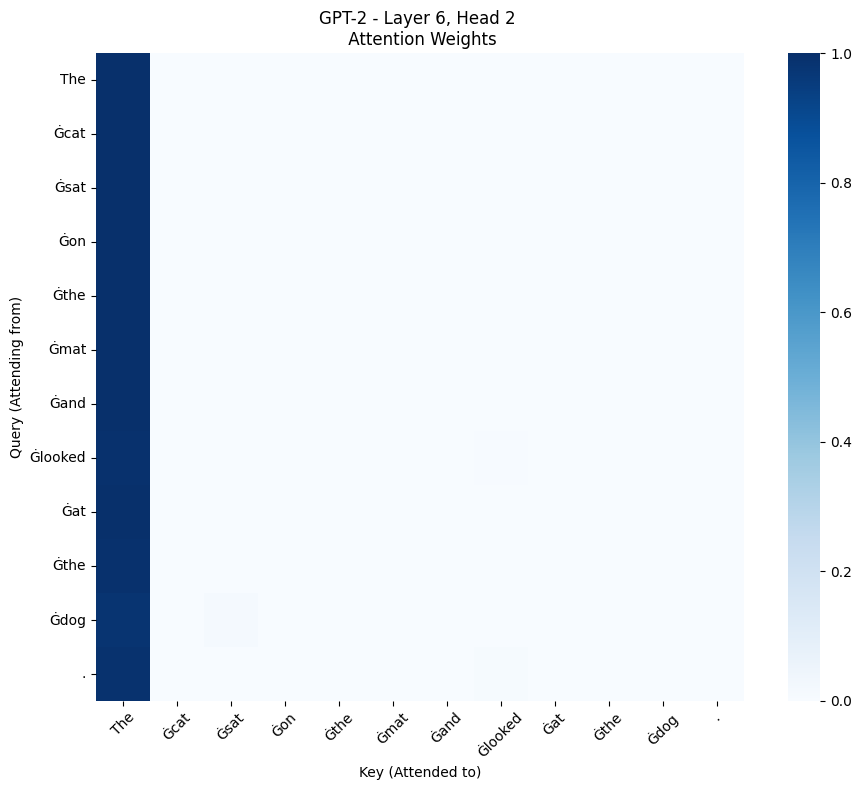

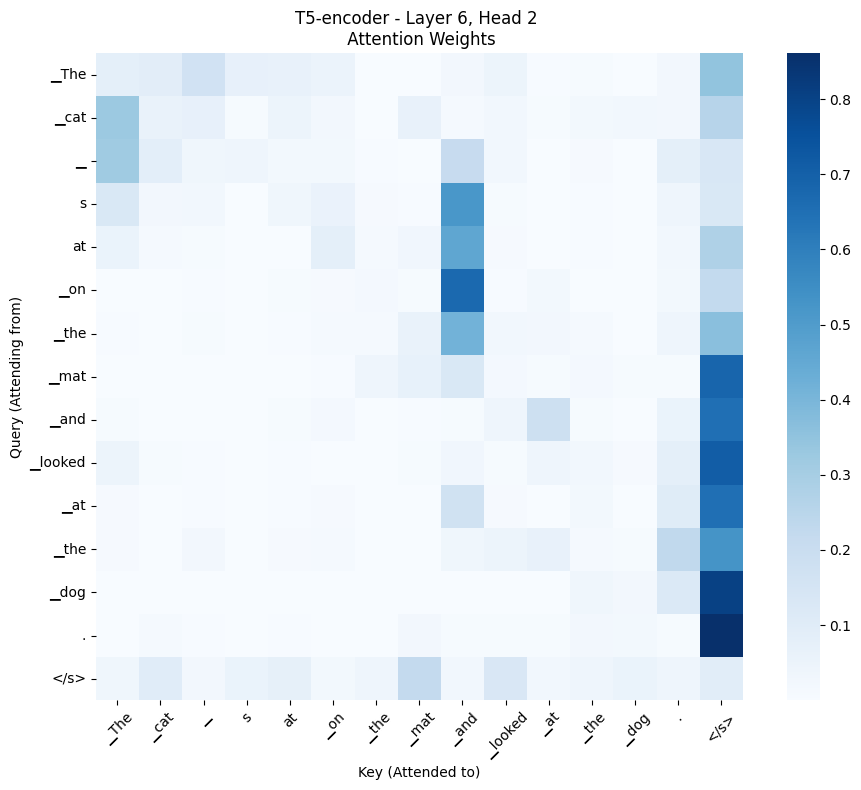

In [62]:
def plot_attention_heatmap(attention_weights, tokens, model_name, layer_idx=0, head_idx=0):
    """
    Создание heatmap для визуализации attention весов
    """
    
    attention_matrix = attention_weights[layer_idx][0][head_idx].detach().numpy()

    plt.figure(figsize=(10, 8))
    sns.heatmap(
       attention_matrix,
       xticklabels=tokens,
       yticklabels=tokens,
       cmap='Blues',
       cbar=True,
       square=True
    )

    plt.title(f'{model_name} - Layer {layer_idx + 1}, Head {head_idx + 1} \n Attention Weights')
    plt.xlabel('Key (Attended to)')
    plt.ylabel('Query (Attending from)')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Визуализируем attention для первого слоя и первой головы
layer_idx_val = 5
head_idx_val = 1
plot_attention_heatmap(bert_attention, bert_tokens, 'BERT', layer_idx=layer_idx_val, head_idx=head_idx_val)
plot_attention_heatmap(gpt2_attention, gpt2_tokens, 'GPT-2', layer_idx=layer_idx_val, head_idx=head_idx_val)
plot_attention_heatmap(t5e_attention, t5e_tokens, 'T5-encoder', layer_idx=layer_idx_val, head_idx=head_idx_val)


### Задание 1.4: Анализ результатов

**TODO: Ответьте на следующие вопросы:**


1. **Какие различия вы заметили в attention patterns между BERT и GPT-2?**

   Для BERT чаще встречается более равномерное распределение между "прошлыми" и "будущими" словами, так как encoder смотрит на всю фразу. Переодически возникают яркие диогонали, но для будущих слов. Есть головы ближе к средним слоям, которые фокусируются на специальном символе CLS, объединяющим всю фразу. Встречаются горизонтальные паттерны на сепараторе (SEP), думаю, как фокус на конце предложения. Встречаются ярко выраженные связи между словами sat->on, looked->at, the->cat

   Для GPT харектерна строгая диогональ, с "пустым" верхним треугольником - все "будущие" слова маскированы. Чаще встречается диагональ "ниже", что говорит, что "прошлые" слова важнее будущих. Разные паттерны "внизу", показывают что ранний контекст важнее будущего, что ожидаемо для decoder. Встречаются горизонтальные паттерны на "The" (первое слово), как фокус на начале предложения.

   Для T5 не вижу характерных особенностей. Встречаются паттерны обеих предыдущих моделей: диогональ "выше" как у BERT, диагональ "в центре" как у GPT. Встречается фокус и на сепараторе и на первом слове.
    
3. **Как изменяются attention веса в разных слоях?**

   Появляются более ярко выраженные паттерны (горизонтальные, диагональные). Веса "не важных" связей становятся близкими к 0, когда "важные" связи получают больший вес. 

4. **Какую роль играют позиционные кодировки?**

   Для BERT чаще встречаются пики на определенных расстояниях, например предлог ищет существительное (looked->at), глагог существительное (looked -> dog). GPT больше обращает внимание на ближайшие токены. T5 имеет более равномерное распределение


## 🚀 Часть 2: Дополнительные задания (30% оценки)

### Задание 2.1: Исследование Multi-Head Attention


MODEL BERT, LAYER 12


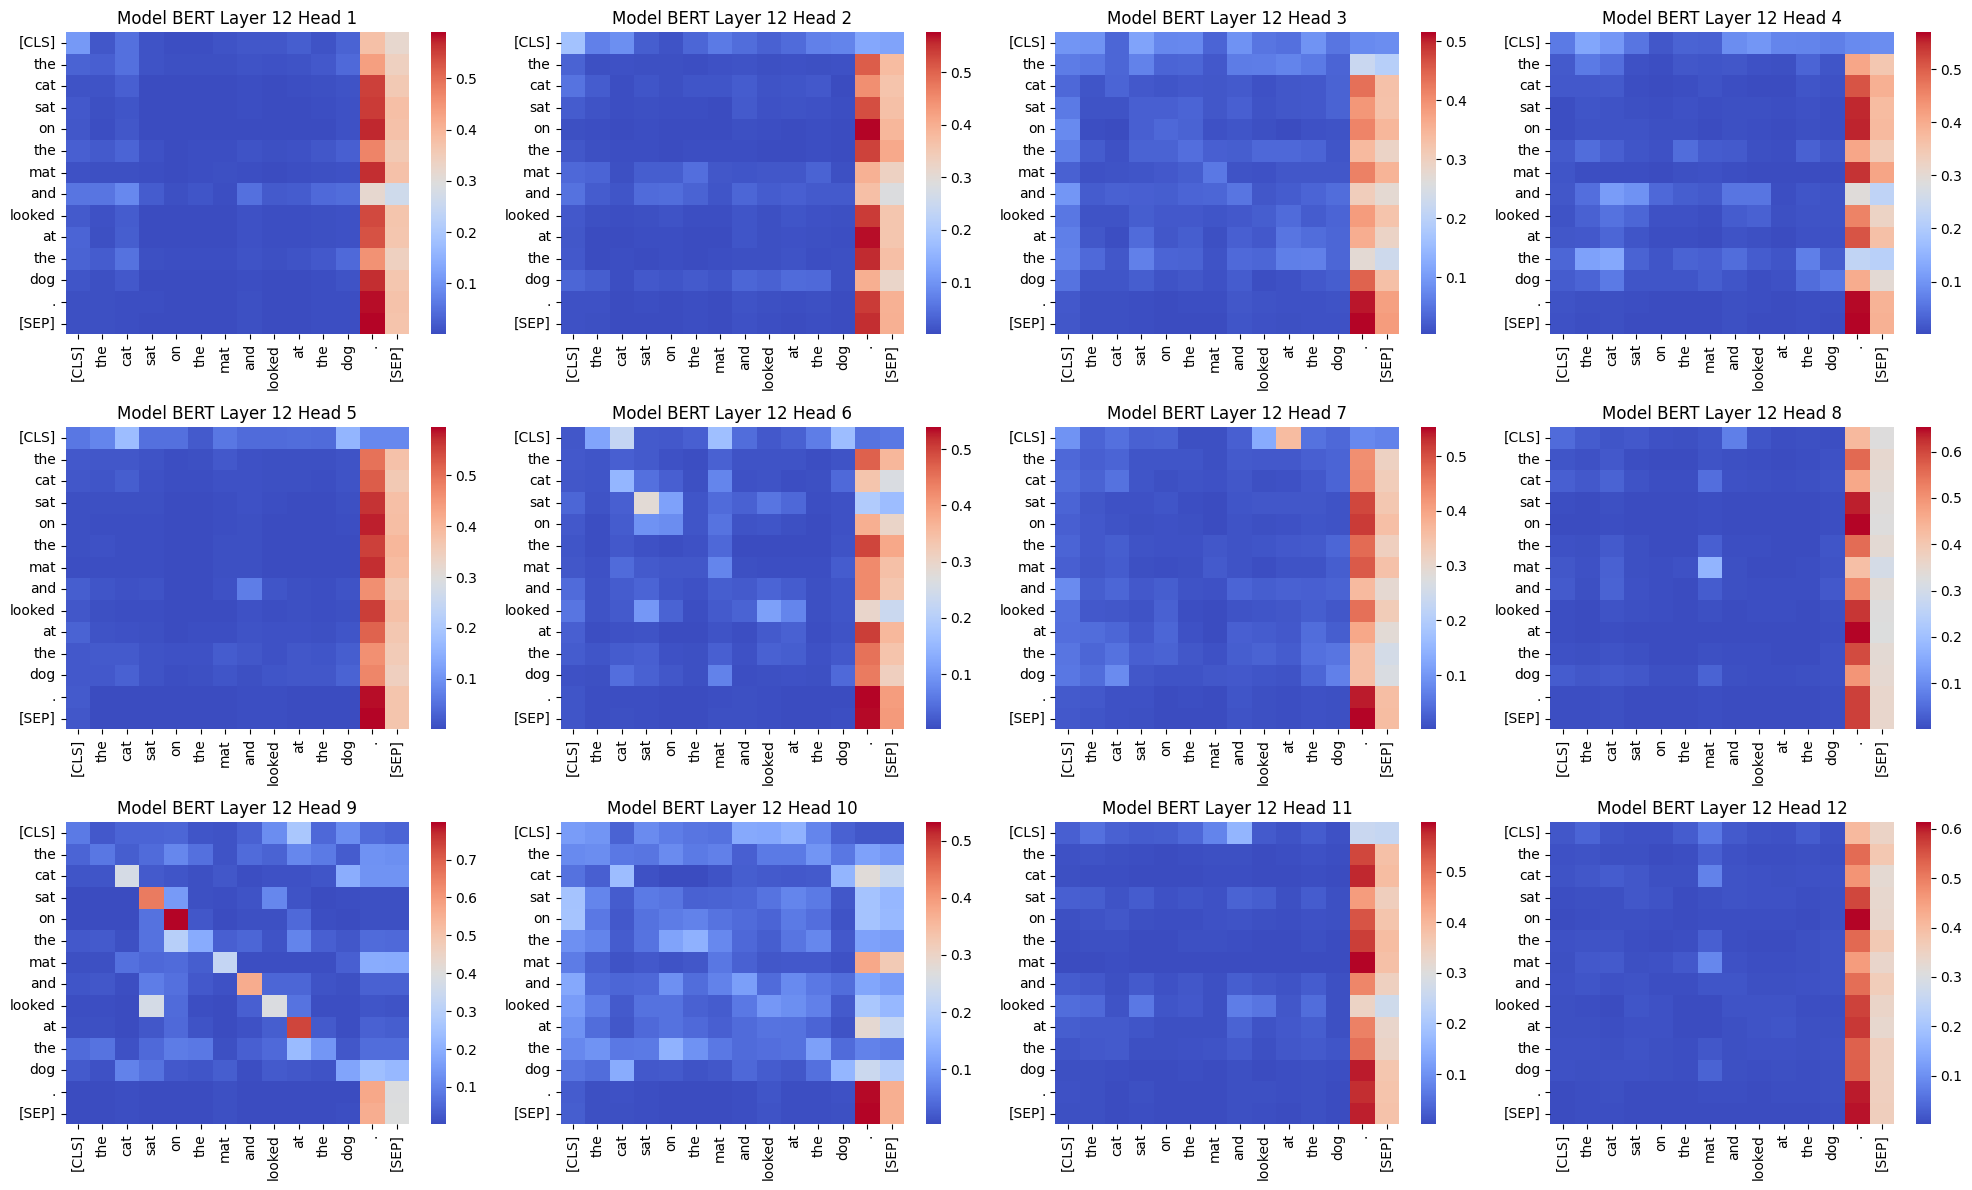

MODEL GPT-2, LAYER 12


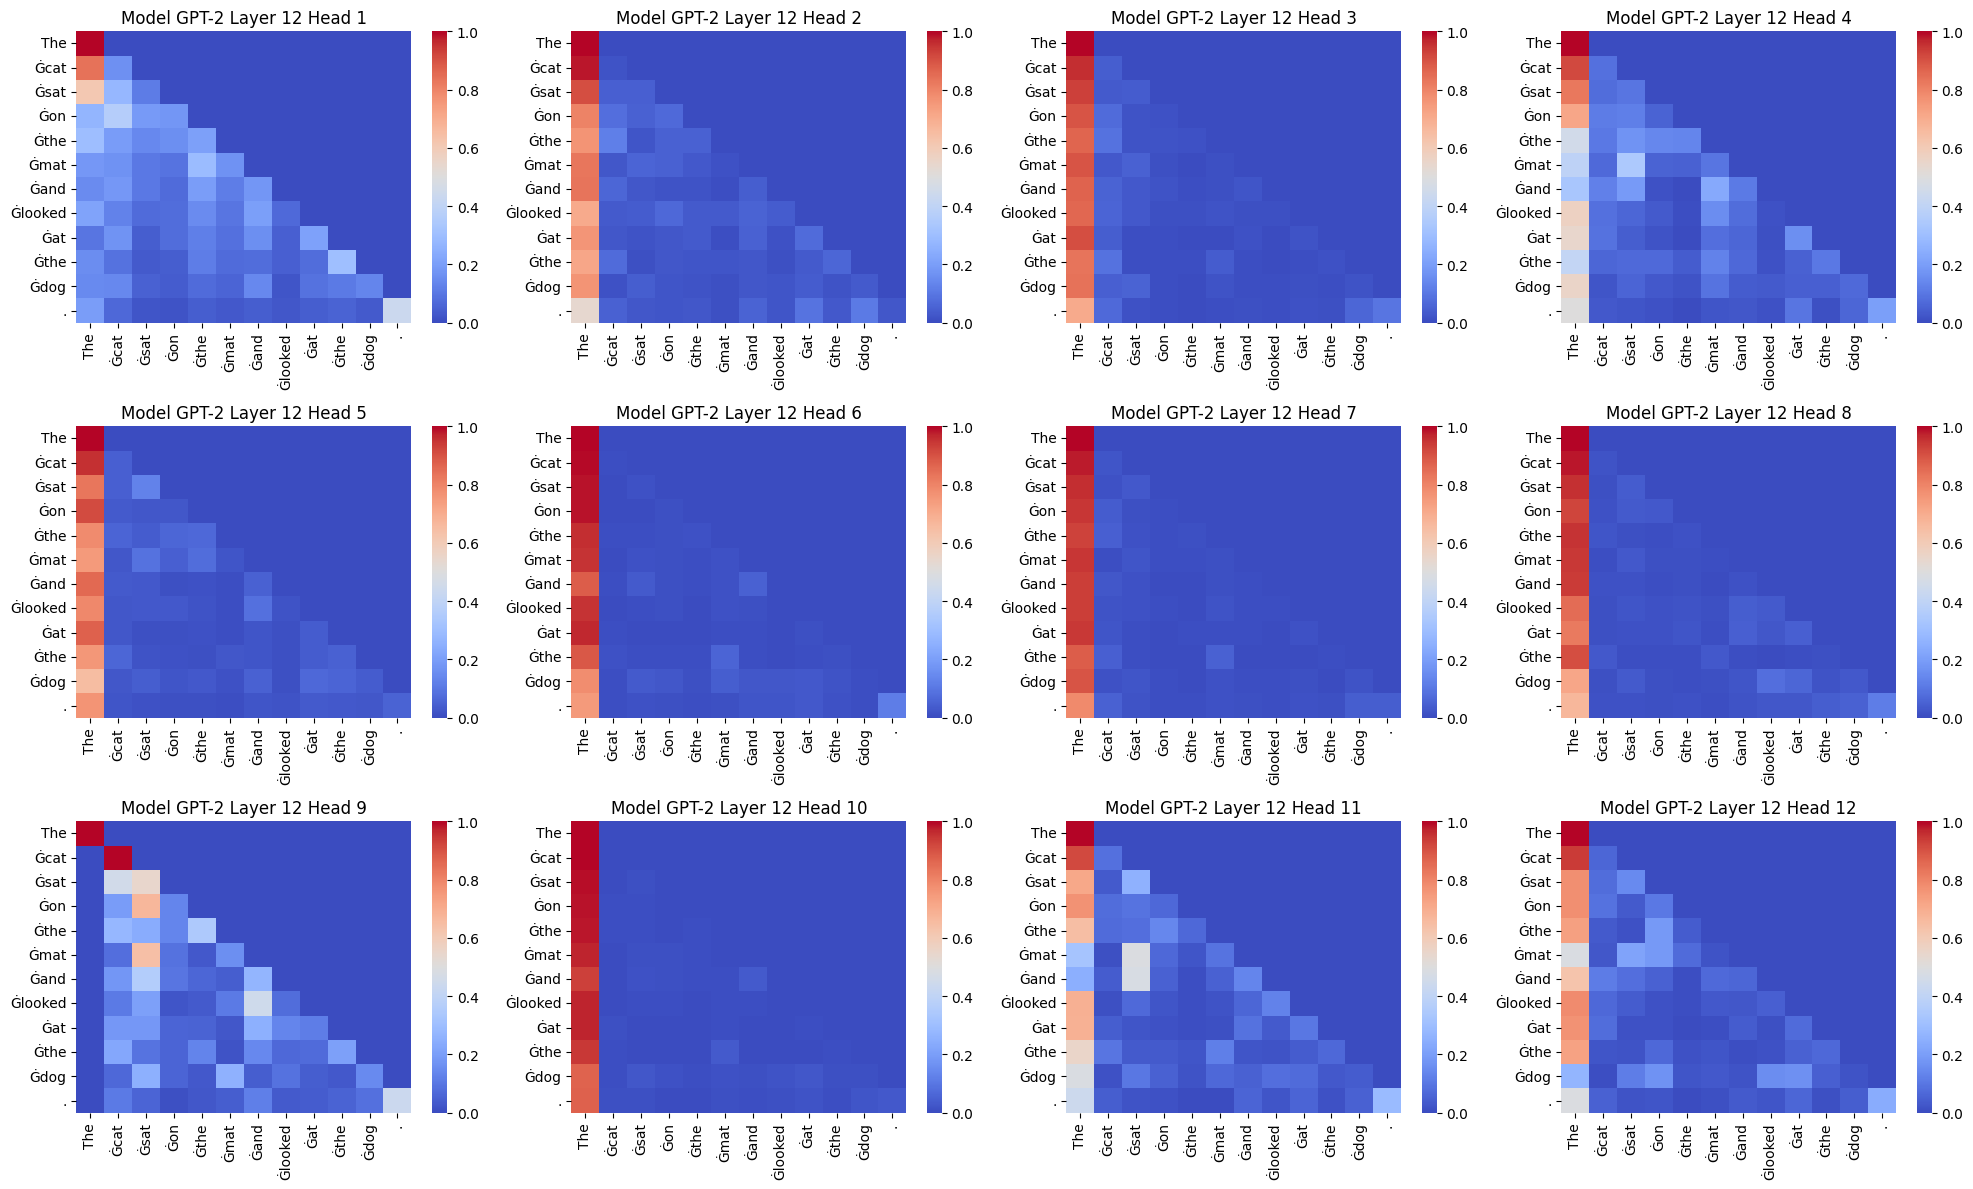

MODEL T5, LAYER 12


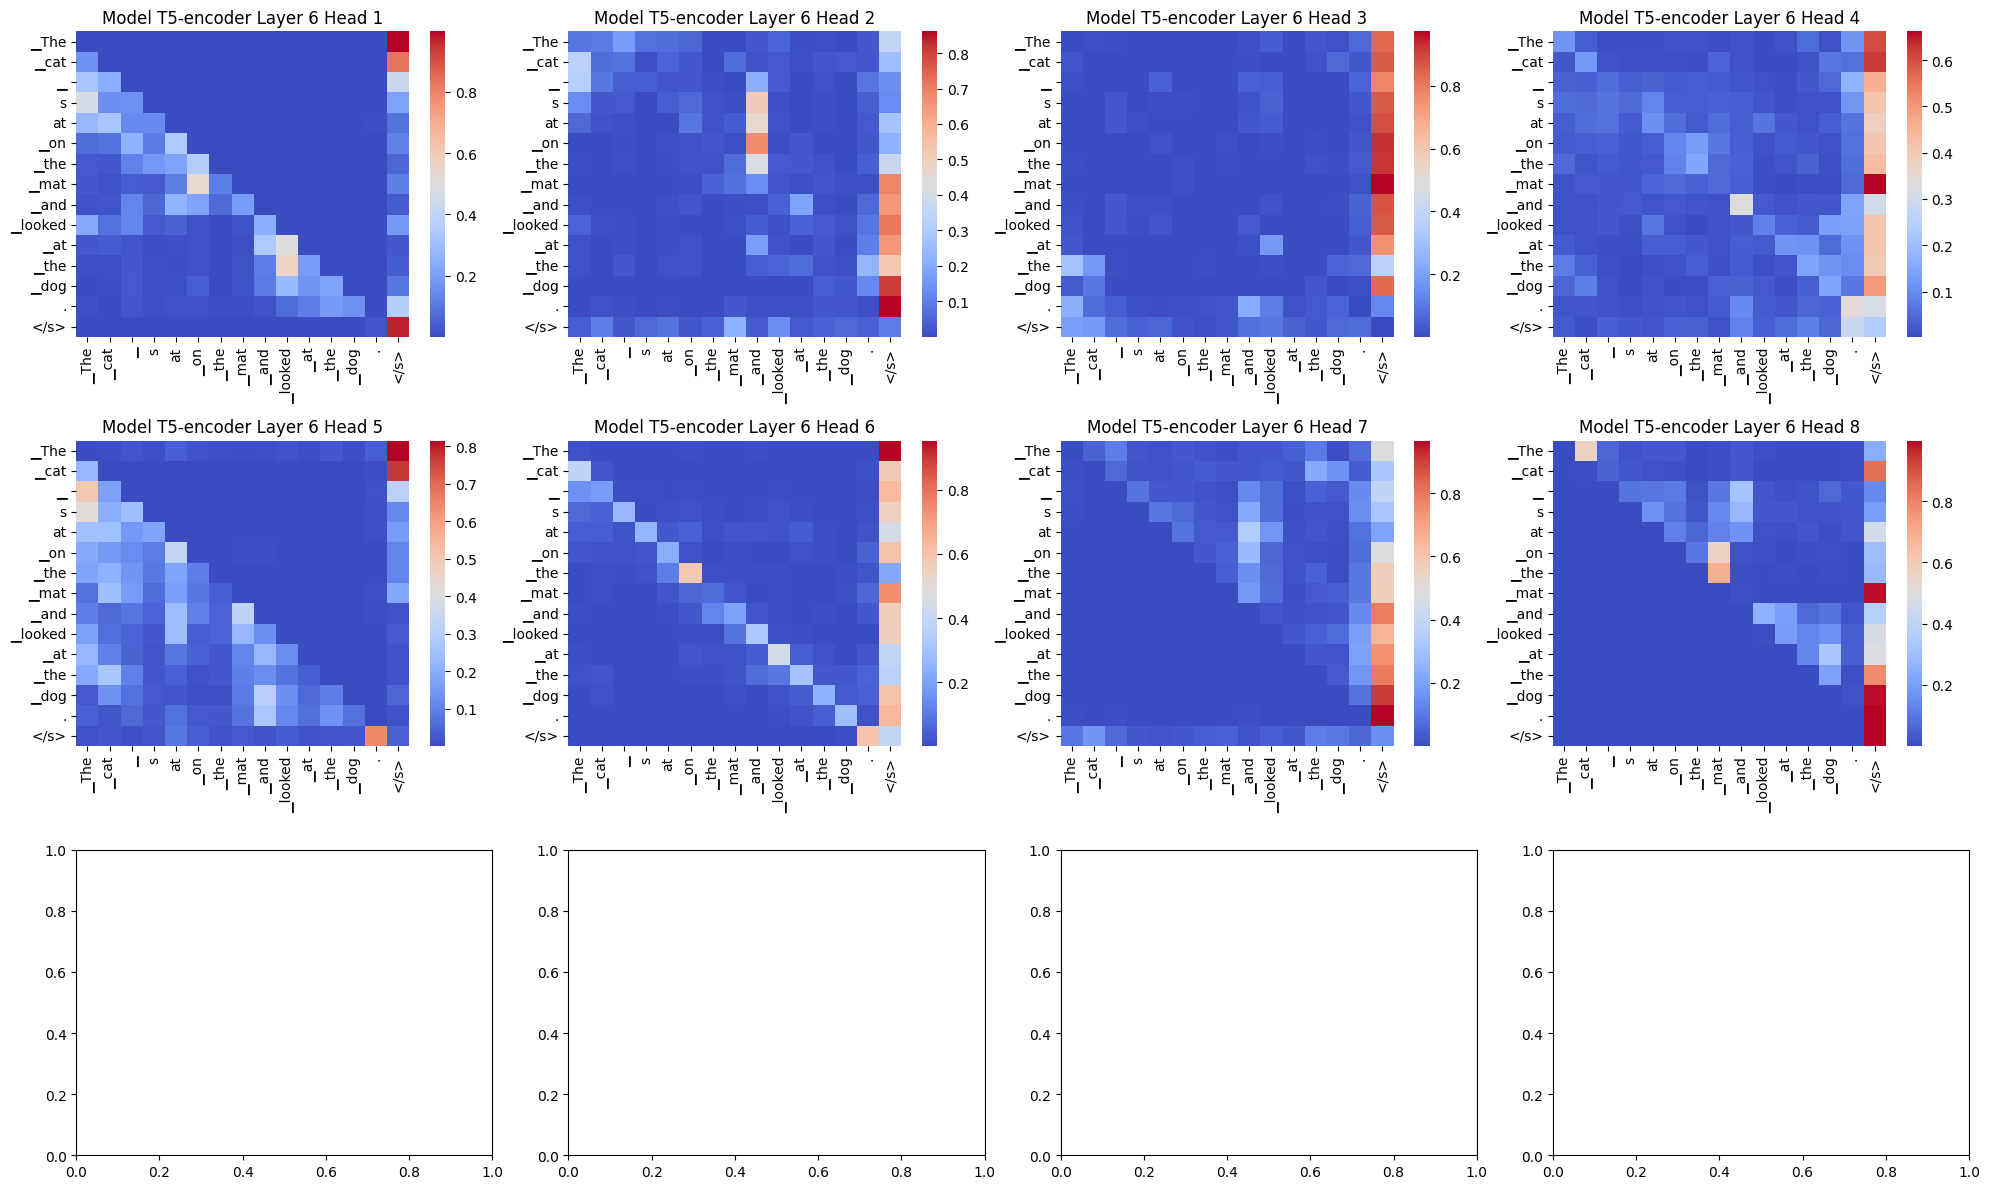

In [48]:
def analyze_multi_head_attention(attention_weights, tokens, model_name, layer_idx=6):
    """
    Анализ того, как разные головы attention фокусируются на разных аспектах
    """

    num_heads = attention_weights[layer_idx][0].shape[0]

    fig, axs = plt.subplots(3, 4, figsize=(20, 12))

    for i in range(num_heads):
        ax = axs[i // 4, i % 4]

        attention = attention_weights[layer_idx][0][i].detach().numpy()
        # attention = attention[1:-1, 1:-1]

        sns.heatmap(
            attention,
            xticklabels=tokens,
            yticklabels=tokens,
            ax=ax,
            cmap="coolwarm"
        )

        ax.set_title(f"Model {model_name} Layer {layer_idx+1} Head {i+1}")
        ax.tick_params(axis="x", rotation=90)
        ax.tick_params(axis="y", rotation=0)

    plt.tight_layout()
    plt.show()

# Анализируем multi-head attention для средних слоев

layer_idx_val = 11
layer_idx_t5_val = 5
print(f"MODEL BERT, LAYER {layer_idx_val + 1}")
analyze_multi_head_attention(bert_attention, bert_tokens, 'BERT', layer_idx=layer_idx_val)
print(f"MODEL GPT-2, LAYER {layer_idx_val + 1}")
analyze_multi_head_attention(gpt2_attention, gpt2_tokens, 'GPT-2', layer_idx=layer_idx_val)
print(f"MODEL T5, LAYER {layer_idx_t5_val + 1}")
analyze_multi_head_attention(t5e_attention, t5e_tokens, 'T5-encoder', layer_idx=layer_idx_t5_val)


### Задание 2.2: Создание attention-карт для русскоязычного текста


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


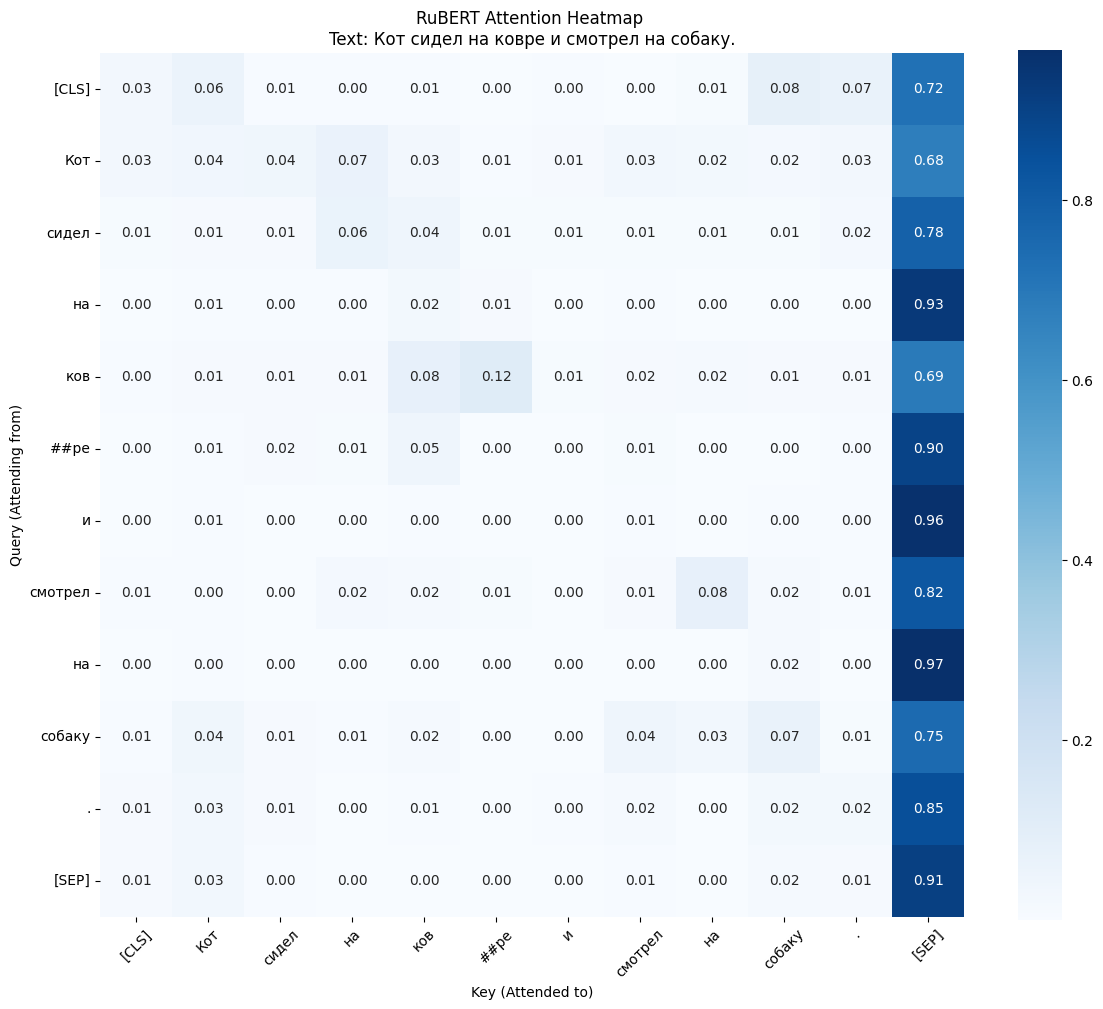

\nТокены: ['[CLS]', 'Кот', 'сидел', 'на', 'ков', '##ре', 'и', 'смотрел', 'на', 'собаку', '.', '[SEP]']
Количество слоев: 12
Количество голов: 12


In [69]:
# TODO: Загрузите русскоязычную модель и проанализируйте attention для русского текста
# ========= РЕШЕНИЕ: =========
from transformers import AutoTokenizer, AutoModel

# Загружаем русскоязычную модель
# Напрмимер можно использовать DeepPavlov/rubert-base-cased
ru_tokenizer = AutoTokenizer.from_pretrained("DeepPavlov/rubert-base-cased")
ru_model = AutoModel.from_pretrained("DeepPavlov/rubert-base-cased", output_attentions=True)

# Русский текст для анализа
russian_text = "Кот сидел на ковре и смотрел на собаку."

def analyze_russian_attention(text, tokenizer, model):
    """
    Анализ attention для русского текста
    """
    # Токенизация
    inputs = ru_tokenizer(russian_text, return_tensors='pt')
    outputs = model(**inputs)
    attention_weights = outputs.attentions
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

    # Создаем heatmap для последнего слоя
    layer_idx = 11
    head_idx = 4
    attention_matrix = attention_weights[layer_idx][0][head_idx].detach().numpy()
    # attention_matrix = attention_matrix[1:-1, 1:-1]

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        attention_matrix,
        xticklabels=tokens,
        yticklabels=tokens,
        cmap='Blues',
        cbar=True,
        square=True,
        annot=True,
        fmt='.2f'
    )

    plt.title(f'RuBERT Attention Heatmap \nText: {text}')
    plt.xlabel('Key (Attended to)')
    plt.ylabel('Query (Attending from)')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return attention_weights, tokens

# Анализируем русский текст
ru_attention, ru_tokens = analyze_russian_attention(russian_text, ru_tokenizer, ru_model)

print(f"\\nТокены: {ru_tokens}")
print(f"Количество слоев: {len(ru_attention)}")
print(f"Количество голов: {ru_attention[0].shape[1]}")


## 📈 Итоговый анализ и выводы

### Задание 3: Сравнительный анализ

**TODO: Сделайте итоговые выводы по результатам всех экспериментов:**


1. **Основные различия между BERT и GPT-2:**

   RuBERT по поведению очень сильно похож на BERT: от "размазанной" картины в первых слоях (нет определенного фокуса внимания), к диоганалям выше середины (будущие слова) и горизонтальным паттернам на CLS (сборный контекст предложения). Итоговые выводы:

   Для BERT чаще встречается более равномерное распределение между "прошлыми" и "будущими" словами, так как encoder смотрит на всю фразу. Переодически возникают яркие диогонали, но для будущих слов. Есть головы ближе к средним слоям, которые фокусируются на специальном символе CLS, объединяющим всю фразу. Встречаются горизонтальные паттерны на сепараторе (SEP), думаю, как фокус на конце предложения. Встречаются ярко выраженные связи между словами sat->on, looked->at, the->cat

   Для GPT харектерна строгая диогональ, с "пустым" верхним треугольником - все "будущие" слова маскированы. Чаще встречается диагональ "ниже", что говорит, что "прошлые" слова важнее будущих. Разные паттерны "внизу", показывают что ранний контекст важнее будущего, что ожидаемо для decoder. Встречаются горизонтальные паттерны на "The" (первое слово), как фокус на начале предложения.

   Для T5 не вижу характерных особенностей. Встречаются паттерны обеих предыдущих моделей: диогональ "выше" как у BERT, диагональ "в центре" как у GPT. Встречается фокус и на сепараторе и на первом слове. 
   

3. **Как attention головы специализируются:**

   1. Связи между определенными частями речи (глагол -> существительное, предлог -> существительное)
   2. Внимание к служебным словам и пунктуации (and, и, ".")
   3. Внимание к соседним токенам (яркая диогональ)
   4. Семантические связи (смотрел -> на -> собаку)

4. **Особенности русскоязычных моделей:**

   "Ковре" разбито на 2 токена. "Ков" и "**ре". Токен окончания "ре" часто подсвечен, сл-но модель фокусируется на окончаниях, те лучше может понять грамматические особенности русского языка. При этом часто яркая связь токена "на" и "ре", вероятно, модель видит как предлог влияет на окончание. В остальном, тот же BERT.

5. **Практические применения полученных знаний:**

   1. Интерпретировать поведение модели по тем словам/фразам, которые она посчитала важным, или наоборот оставила без фокуса
   2. Проверять "предрассудки" модели. Например, профессия->пол
   3. Убирать "мертвые"/повторяющиеся головы для оптимизации работы модели
   4. Понимает ли модель грамматику. Связи между существительное->глагол, предлог->существительное
  


## 🎯 Заключение

В этом задании вы:
- ✅ Изучили механизмы attention в трансформерах
- ✅ Сравнили разные архитектуры (BERT vs GPT-2)
- ✅ Проанализировали специализацию attention голов
- ✅ Работали с русскоязычными моделями

Полученные навыки визуализации и анализа attention будут полезны для:
- Отладки и оптимизации моделей
- Объяснения решений AI-систем
- Выбора подходящей архитектуры для задач
- Интерпретации поведения моделей

## 📋 Критерии сдачи ДЗ

### Обязательная часть (70% оценки):
- [x] Загружены и настроены модели BERT и GPT-2
- [x] Реализована функция получения attention весов
- [x] Создана базовая визуализация attention heatmap
- [x] Даны ответы на аналитические вопросы

### Дополнительная часть (30% оценки):
- [x] Проанализированы multi-head attention паттерны
- [x] Работа с русскоязычной моделью
- [x] Итоговый сравнительный анализ

**Удачи в дальнейшем изучении трансформеров! 🚀**
